# Visualizing Data with Pie Charts

**Author:** Mitadru Deb  
**Date:** February 2026

This notebook uses pie charts to visualize the composition and distribution of categorical data in the developer survey, focusing on technology preferences and usage patterns.

## Importing Libraries

I'll import the necessary libraries for data analysis and visualization.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 8)

## Loading the Dataset

I'll download and load the survey data.

In [5]:
# Download the dataset
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
# Load the data
df = pd.read_csv(url)

In [6]:

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (65437, 114)

First few rows:


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## Task 1: Visualizing Data Composition

### Pie Chart 1: Top 5 Databases Respondents Want to Work With

I'll visualize the most desired databases among developers.

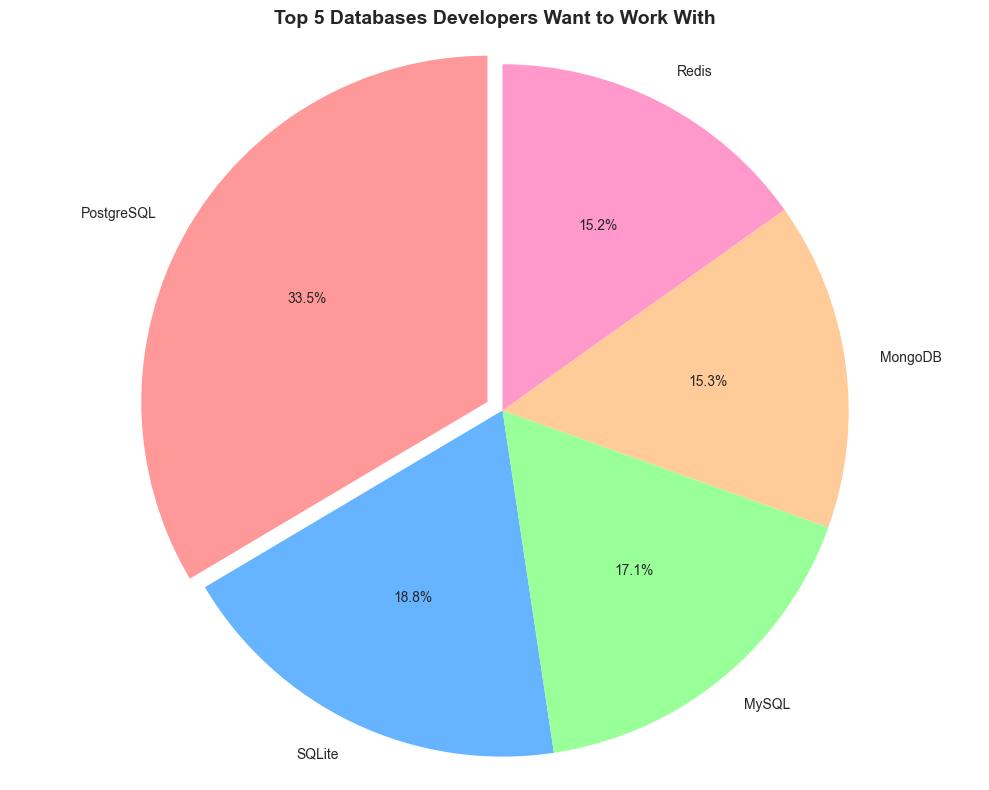


Top 5 Databases:
DatabaseWantToWorkWith
PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: count, dtype: int64


In [7]:
# Check for database column
if 'DatabaseWantToWorkWith' in df.columns:
    # Prepare data - split semicolon-separated values
    db_data = df['DatabaseWantToWorkWith'].dropna()
    all_databases = db_data.str.split(';').explode()
    
    # Get top 5 databases
    top_5_db = all_databases.value_counts().head(5)
    
    # Create pie chart
    plt.figure(figsize=(10, 8))
    colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc']
    plt.pie(top_5_db.values, labels=top_5_db.index, autopct='%1.1f%%', 
           startangle=90, colors=colors, explode=[0.05, 0, 0, 0, 0])
    plt.title('Top 5 Databases Developers Want to Work With', fontsize=14, fontweight='bold')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 5 Databases:")
    print(top_5_db)
else:
    print("DatabaseWantToWorkWith column not found")

### Pie Chart 2: Top 5 Developer Types

I'll visualize the distribution of developer roles.

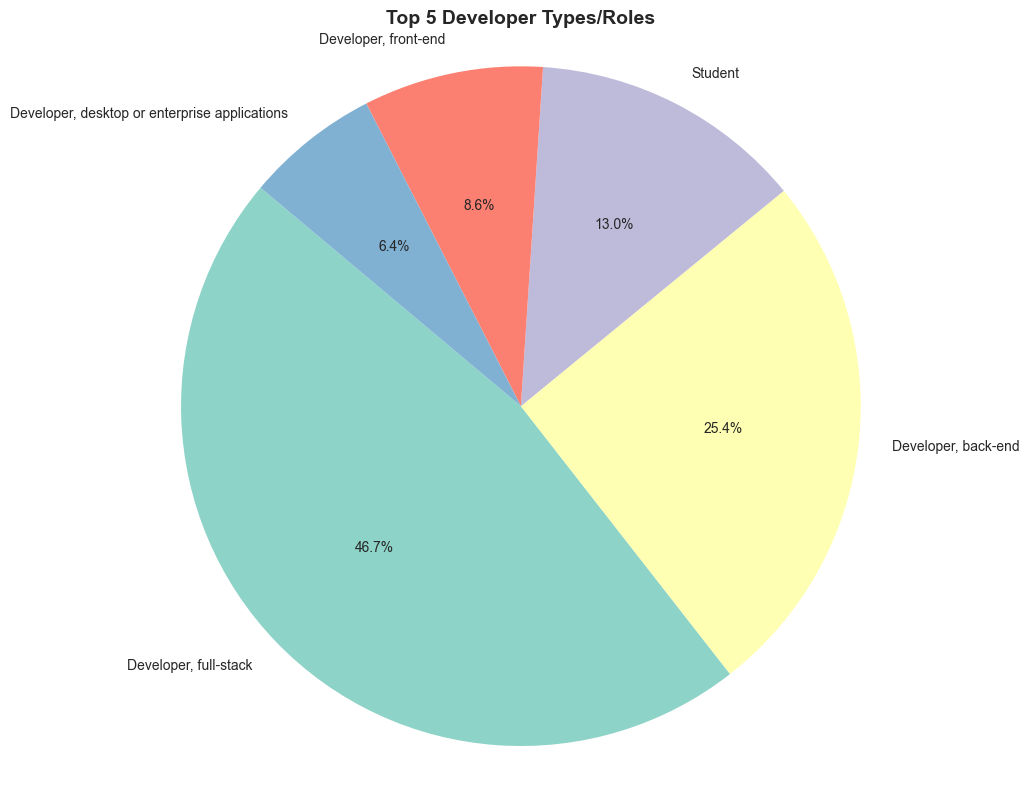


Top 5 Developer Types:
DevType
Developer, full-stack                            18260
Developer, back-end                               9928
Student                                           5102
Developer, front-end                              3349
Developer, desktop or enterprise applications     2493
Name: count, dtype: int64


In [8]:
# Check for developer type column
dev_col = None
for col in ['DevType', 'MainBranch']:
    if col in df.columns:
        dev_col = col
        break

if dev_col:
    # For DevType, split if it contains multiple values
    if dev_col == 'DevType':
        dev_data = df[dev_col].dropna()
        all_dev_types = dev_data.str.split(';').explode()
        top_5_dev = all_dev_types.value_counts().head(5)
    else:
        # For MainBranch, just count
        top_5_dev = df[dev_col].value_counts().head(5)
    
    # Create pie chart
    plt.figure(figsize=(10, 8))
    colors = ['#8dd3c7', '#ffffb3', '#bebada', '#fb8072', '#80b1d3']
    plt.pie(top_5_dev.values, labels=top_5_dev.index, autopct='%1.1f%%', 
           startangle=140, colors=colors)
    plt.title('Top 5 Developer Types/Roles', fontsize=14, fontweight='bold')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 5 Developer Types:")
    print(top_5_dev)
else:
    print("Developer type column not found")

### Pie Chart 3: Operating Systems Used Professionally

I'll visualize the distribution of professional operating system usage.

In [9]:
# Check for OS column
os_col = None
for col in ['OpSysProfessional use', 'OpSysProf', 'OpSys']:
    if col in df.columns:
        os_col = col
        break

if os_col:
    # Get OS data
    os_data = df[os_col].dropna()
    
    # Check if ANY row contains multiple values (not just the first row)
    if os_data.str.contains(';', na=False).any():
        all_os = os_data.str.split(';').explode().str.strip()
        top_os = all_os.value_counts().head(6)
    else:
        top_os = os_data.value_counts().head(6)
    
    # Create pie chart
    plt.figure(figsize=(10, 8))
    colors = ['#fdb462', '#b3de69', '#fccde5', '#d9d9d9', '#bc80bd', '#ccebc5']
    plt.pie(top_os.values, labels=top_os.index, autopct='%1.1f%%', 
           startangle=45, colors=colors)
    plt.title('Operating Systems Used Professionally', fontsize=14, fontweight='bold')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    
    print("\nTop Operating Systems:")
    print(top_os)
else:
    print("Operating system column not found")

## Task 2: Additional Visualizations

### Pie Chart 4: Top 5 Programming Languages

I'll visualize the most commonly used programming languages.

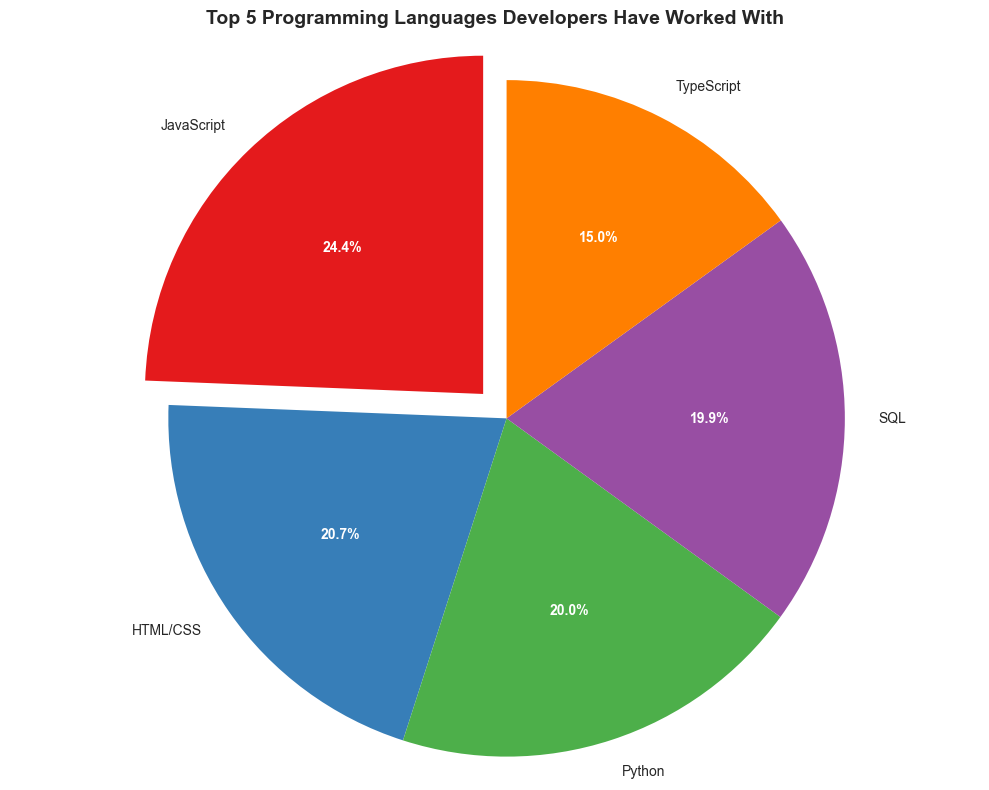


Top 5 Programming Languages:
LanguageHaveWorkedWith
JavaScript    37492
HTML/CSS      31816
Python        30719
SQL           30682
TypeScript    23150
Name: count, dtype: int64


In [10]:
# Check for language column
if 'LanguageHaveWorkedWith' in df.columns:
    # Prepare data
    lang_data = df['LanguageHaveWorkedWith'].dropna()
    all_languages = lang_data.str.split(';').explode()
    
    # Get top 5 languages
    top_5_lang = all_languages.value_counts().head(5)
    
    # Create pie chart
    plt.figure(figsize=(10, 8))
    colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
    wedges, texts, autotexts = plt.pie(top_5_lang.values, labels=top_5_lang.index, 
                                        autopct='%1.1f%%', startangle=90, colors=colors,
                                        explode=[0.1, 0, 0, 0, 0])
    
    # Make percentage text bold
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    plt.title('Top 5 Programming Languages Developers Have Worked With', 
             fontsize=14, fontweight='bold')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 5 Programming Languages:")
    print(top_5_lang)
else:
    print("LanguageHaveWorkedWith column not found")

### Pie Chart 5: Top Collaboration Tools

I'll visualize the most popular collaboration tools used professionally.

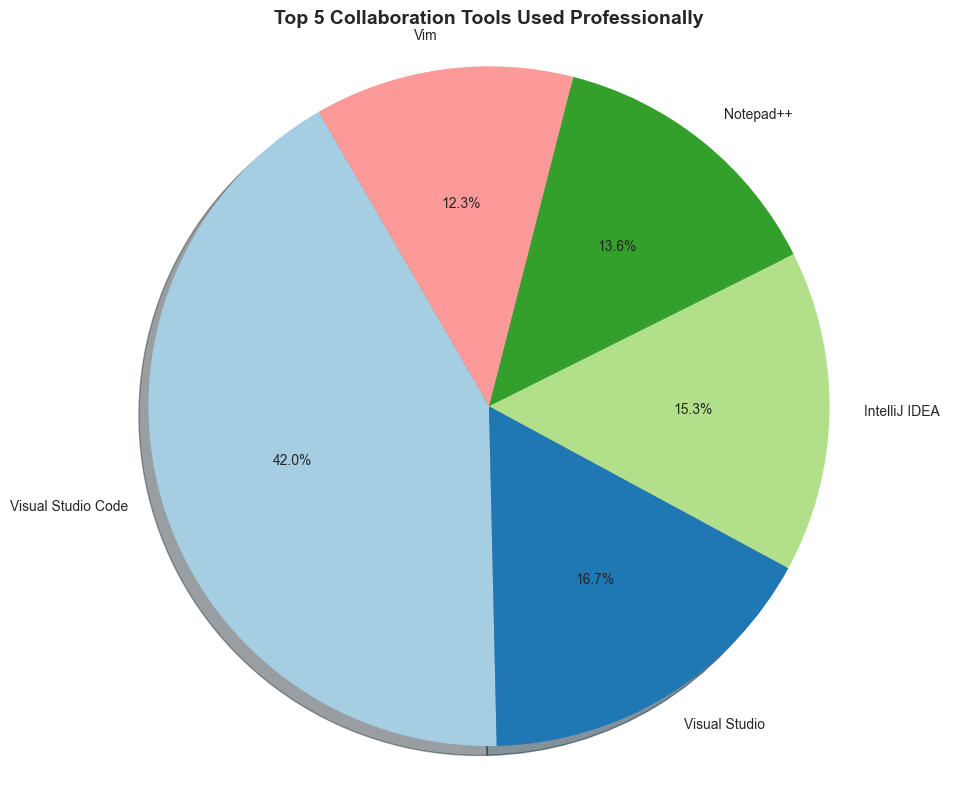


Top 5 Collaboration Tools:
NEWCollabToolsHaveWorkedWith
Visual Studio Code    42751
Visual Studio         17021
IntelliJ IDEA         15555
Notepad++             13874
Vim                   12523
Name: count, dtype: int64


In [11]:
# Check for collaboration tools column
if 'NEWCollabToolsHaveWorkedWith' in df.columns:
    # Prepare data
    collab_data = df['NEWCollabToolsHaveWorkedWith'].dropna()
    all_tools = collab_data.str.split(';').explode()
    
    # Get top 5 tools
    top_5_tools = all_tools.value_counts().head(5)
    
    # Create pie chart
    plt.figure(figsize=(10, 8))
    colors = ['#a6cee3', '#1f78b4', '#b2df8a', '#33a02c', '#fb9a99']
    plt.pie(top_5_tools.values, labels=top_5_tools.index, autopct='%1.1f%%', 
           startangle=120, colors=colors, shadow=True)
    plt.title('Top 5 Collaboration Tools Used Professionally', fontsize=14, fontweight='bold')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 5 Collaboration Tools:")
    print(top_5_tools)
else:
    print("NEWCollabToolsHaveWorkedWith column not found")

## Task 3: Analyzing and Interpreting Composition

### Pie Chart 6: Most Admired Programming Languages

I'll visualize the programming languages developers admire most.

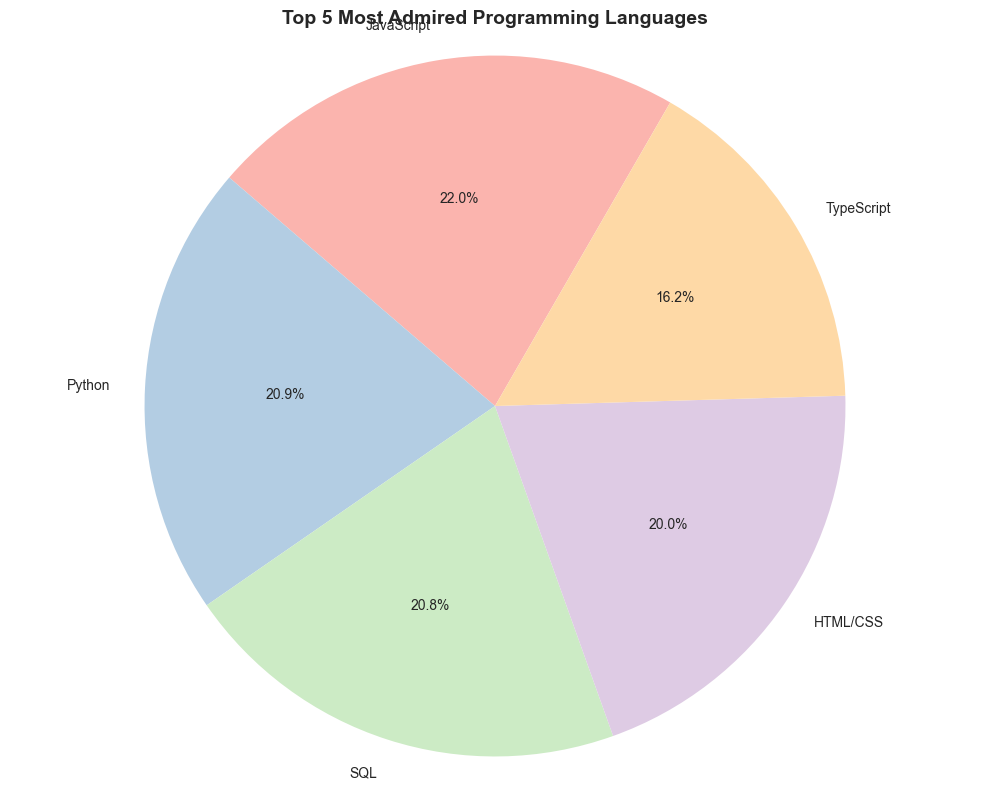


Top 5 LanguageAdmired:
LanguageAdmired
JavaScript    21869
Python        20774
SQL           20692
HTML/CSS      19851
TypeScript    16079
Name: count, dtype: int64


In [12]:
# Check for admired languages column
admired_col = None
for col in ['LanguageAdmired', 'LanguageWantToWorkWith']:
    if col in df.columns:
        admired_col = col
        break

if admired_col:
    # Prepare data
    admired_data = df[admired_col].dropna()
    all_admired = admired_data.str.split(';').explode()
    
    # Get top 5 admired languages
    top_5_admired = all_admired.value_counts().head(5)
    
    # Create pie chart
    plt.figure(figsize=(10, 8))
    colors = ['#fbb4ae', '#b3cde3', '#ccebc5', '#decbe4', '#fed9a6']
    plt.pie(top_5_admired.values, labels=top_5_admired.index, autopct='%1.1f%%', 
           startangle=60, colors=colors)
    plt.title('Top 5 Most Admired Programming Languages', fontsize=14, fontweight='bold')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    
    print(f"\nTop 5 {admired_col}:")
    print(top_5_admired)
else:
    print("Admired languages column not found")

### Pie Chart 7: Tools Used for AI Development

I'll visualize the AI development tools currently being used.

In [13]:
# Check for AI tools column
ai_col = None
for col in ['AIToolCurrently Using', 'AIToolCurrentlyUsing', 'AIToolCurrently', 'AISearch']:
    if col in df.columns:
        ai_col = col
        break

if ai_col:
    # Prepare data
    ai_data = df[ai_col].dropna()
    
    # Check if ANY row contains multiple values (not just the first row)
    if ai_data.str.contains(';', na=False).any():
        all_ai_tools = ai_data.str.split(';').explode().str.strip()
        top_5_ai = all_ai_tools.value_counts().head(5)
    else:
        top_5_ai = ai_data.value_counts().head(5)
    
    # Create pie chart
    plt.figure(figsize=(10, 8))
    colors = ['#8dd3c7', '#ffffb3', '#bebada', '#fb8072', '#80b1d3']
    plt.pie(top_5_ai.values, labels=top_5_ai.index, autopct='%1.1f%%', 
           startangle=180, colors=colors, explode=[0.05, 0, 0, 0, 0])
    plt.title('Top 5 AI Development Tools Currently Used', fontsize=14, fontweight='bold')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 5 AI Tools:")
    print(top_5_ai)
else:
    print("AI tools column not found")

### Pie Chart 8: Preferred Web Frameworks

I'll visualize the web frameworks developers want to work with.

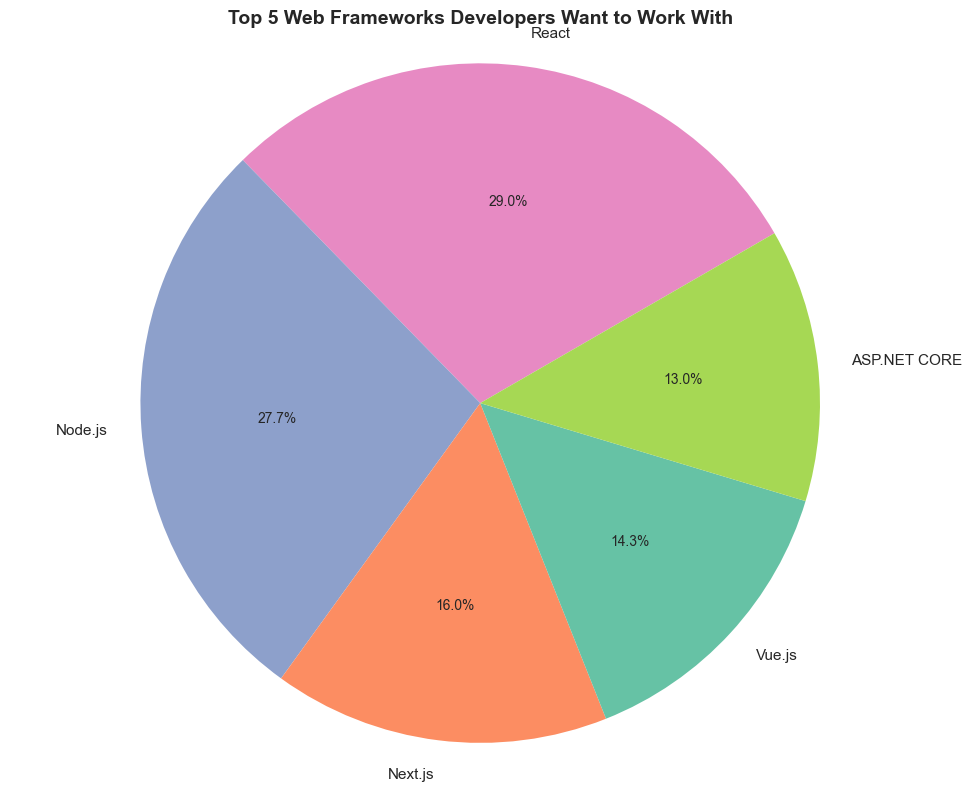


Top 5 Web Frameworks:
WebframeWantToWorkWith
React           15404
Node.js         14735
Next.js          8507
Vue.js           7604
ASP.NET CORE     6905
Name: count, dtype: int64


In [14]:
# Check for web framework column
if 'WebframeWantToWorkWith' in df.columns:
    # Prepare data
    webframe_data = df['WebframeWantToWorkWith'].dropna()
    all_frameworks = webframe_data.str.split(';').explode()
    
    # Get top 5 frameworks
    top_5_frameworks = all_frameworks.value_counts().head(5)
    
    # Create pie chart
    plt.figure(figsize=(10, 8))
    colors = ['#e78ac3', '#8da0cb', '#fc8d62', '#66c2a5', '#a6d854']
    wedges, texts, autotexts = plt.pie(top_5_frameworks.values, labels=top_5_frameworks.index, 
                                        autopct='%1.1f%%', startangle=30, colors=colors)
    
    # Style the text
    for text in texts:
        text.set_fontsize(11)
    
    plt.title('Top 5 Web Frameworks Developers Want to Work With', 
             fontsize=14, fontweight='bold')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 5 Web Frameworks:")
    print(top_5_frameworks)
else:
    print("WebframeWantToWorkWith column not found")

### Pie Chart 9: Most Desired Embedded Technologies

I'll visualize the embedded technologies developers want to work with.

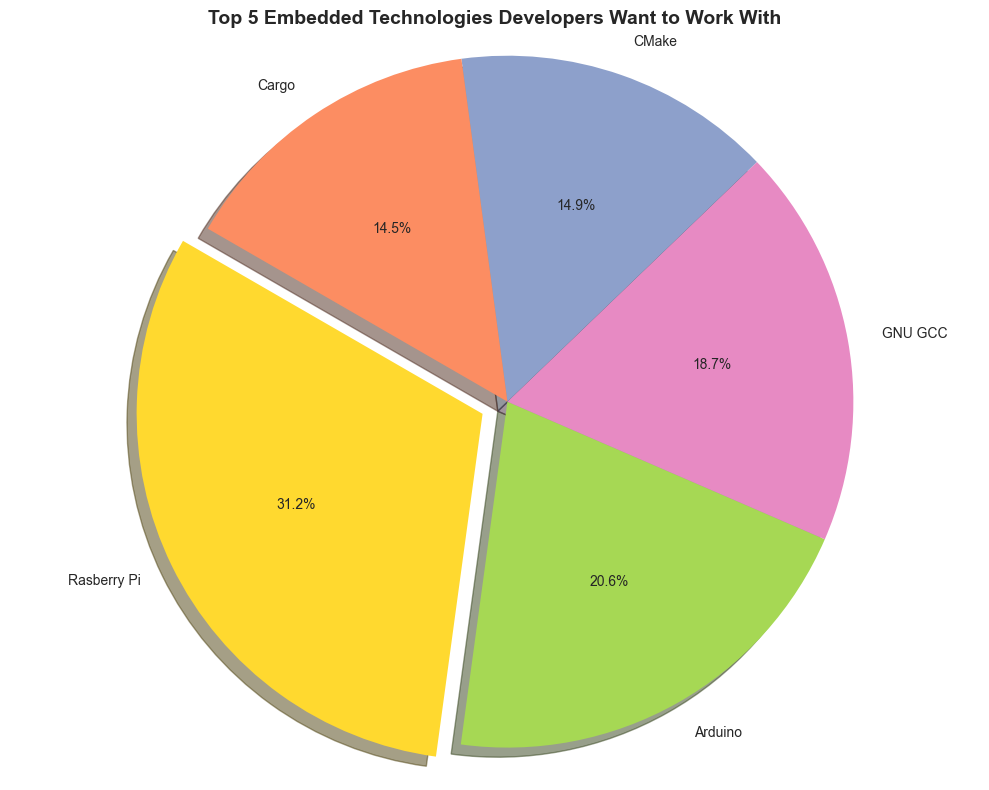


Top 5 Embedded Technologies:
EmbeddedWantToWorkWith
Rasberry Pi    9792
Arduino        6482
GNU GCC        5870
CMake          4693
Cargo          4567
Name: count, dtype: int64


In [15]:
# Check for embedded technologies column
if 'EmbeddedWantToWorkWith' in df.columns:
    # Prepare data
    embedded_data = df['EmbeddedWantToWorkWith'].dropna()
    all_embedded = embedded_data.str.split(';').explode()
    
    # Get top 5 embedded technologies
    top_5_embedded = all_embedded.value_counts().head(5)
    
    # Create pie chart
    plt.figure(figsize=(10, 8))
    colors = ['#ffd92f', '#a6d854', '#e78ac3', '#8da0cb', '#fc8d62']
    plt.pie(top_5_embedded.values, labels=top_5_embedded.index, autopct='%1.1f%%', 
           startangle=150, colors=colors, explode=[0.08, 0, 0, 0, 0], shadow=True)
    plt.title('Top 5 Embedded Technologies Developers Want to Work With', 
             fontsize=14, fontweight='bold')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 5 Embedded Technologies:")
    print(top_5_embedded)
else:
    print("EmbeddedWantToWorkWith column not found")

## Summary

In this notebook, I created 9 pie charts to visualize the composition of categorical data in the developer survey:

**Task 1: Data Composition**
- Top 5 databases developers want to work with
- Distribution of developer types/roles
- Operating systems used professionally

**Task 2: Additional Visualizations**
- Top 5 programming languages developers have worked with
- Top collaboration tools used professionally

**Task 3: Analyzing Composition**
- Most admired programming languages
- AI development tools currently in use
- Preferred web frameworks
- Most desired embedded technologies

### Key Insights from Pie Charts:

Pie charts are excellent for:
- **Showing proportions** - Each slice represents a percentage of the whole
- **Comparing categories** - Easy to see which category is dominant
- **Quick interpretation** - Visual hierarchy is immediately apparent
- **Limited categories** - Best with 5-7 slices for clarity

### Visualization Enhancements Used:

- **Color schemes** - Different palettes for each chart
- **Exploded slices** - Highlight the top category
- **Shadow effects** - Add depth to certain charts
- **Percentage labels** - Show exact proportions
- **Custom styling** - Bold text and adjusted font sizes

These pie charts reveal technology preferences, tool adoption patterns, and the distribution of developer roles in the survey population.